# 02. EDA and Feature Engineering


## 1. Load Data and Train-Test Split


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
import seaborn as sns


In [2]:
df = pd.read_csv(
    "forest_fires_clean.csv",
    )

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["Classes"],     # keep same proportion of classes in train and test sets
    random_state=42
)

## 2. Exploratory Data Analysis


### 2.1 Target Distribution


In [3]:
# Check for class imbalance in the training set
class_counts = train_df["Classes"].value_counts()
class_percentages = train_df["Classes"].value_counts(normalize=True) * 100

print(class_counts)
print(class_percentages)

Classes
fire        110
not fire     85
Name: count, dtype: int64
Classes
fire        56.410256
not fire    43.589744
Name: proportion, dtype: float64


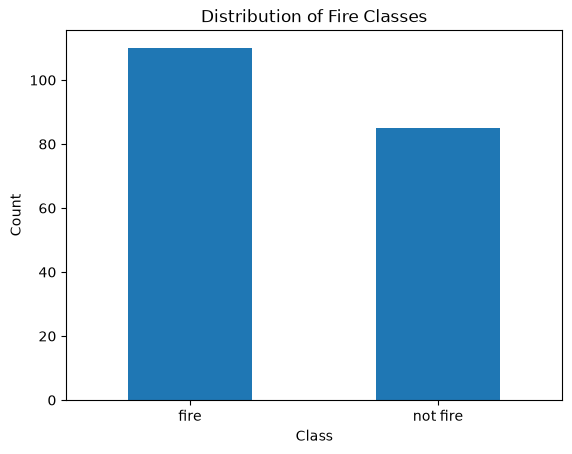

In [4]:
class_counts.plot(kind="bar")

plt.title("Distribution of Fire Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### 2.2 Numerical Feature Distributions


In [5]:
# Check distribution of numerical features

numeric_features = [
    "Temperature", "RH", "Ws", "Rain",
    "FFMC", "DMC", "DC", "ISI", "BUI", "FWI"
]

train_df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,195.0,32.271795,3.532321,22.0,30.00,32.0,35.00,42.0
RH,195.0,62.143590,14.629088,24.0,53.00,63.0,73.50,90.0
Ws,195.0,15.615385,2.813951,8.0,14.00,15.0,17.00,29.0
Rain,195.0,0.706154,1.863281,0.0,0.00,0.0,0.50,16.8
FFMC,195.0,78.255897,13.736095,36.1,73.00,83.1,88.45,96.0
DMC,195.0,15.175385,12.809911,0.9,6.00,11.4,21.15,65.9
DC,195.0,50.895897,49.244958,7.0,14.65,33.1,73.45,220.4
ISI,195.0,4.779487,4.155643,0.0,1.50,3.3,7.30,19.0
BUI,195.0,17.250769,14.740754,1.4,6.30,12.5,23.80,68.0
FWI,195.0,7.153846,7.500813,0.0,0.80,4.2,11.75,30.3


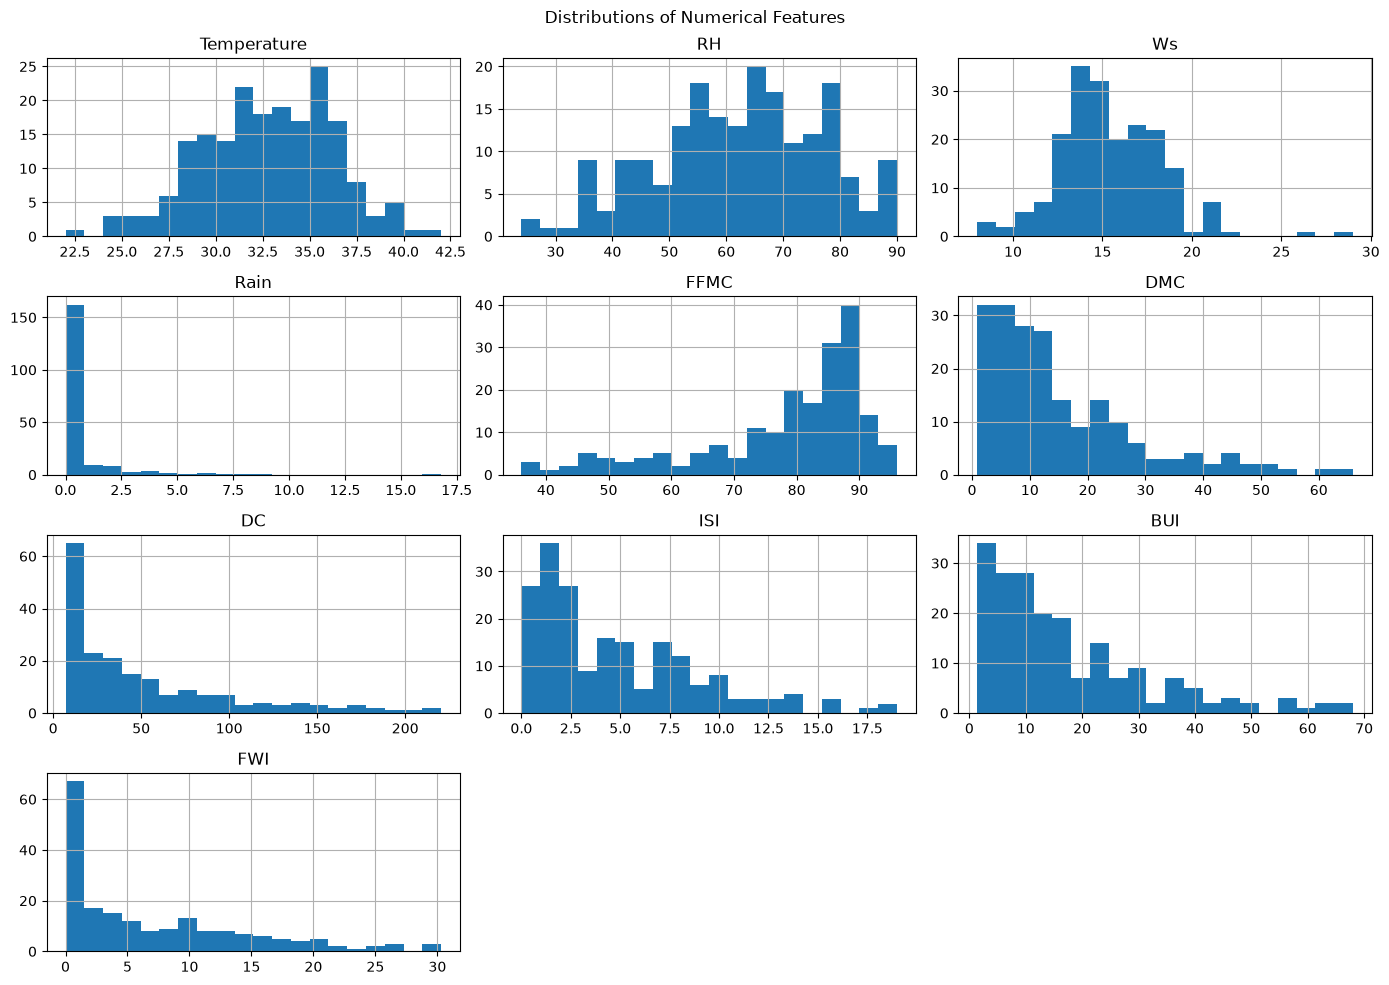

In [6]:
train_df[numeric_features].hist(
    bins=20,
    figsize=(14, 10)
)

plt.suptitle("Distributions of Numerical Features")
plt.tight_layout()
plt.show()

# Rain, DMC, DC, ISI, BUI, and FWI are strongly right-skewed; FFMC is left-skewed.

### 2.3 Relationships Between Numerical Predictors


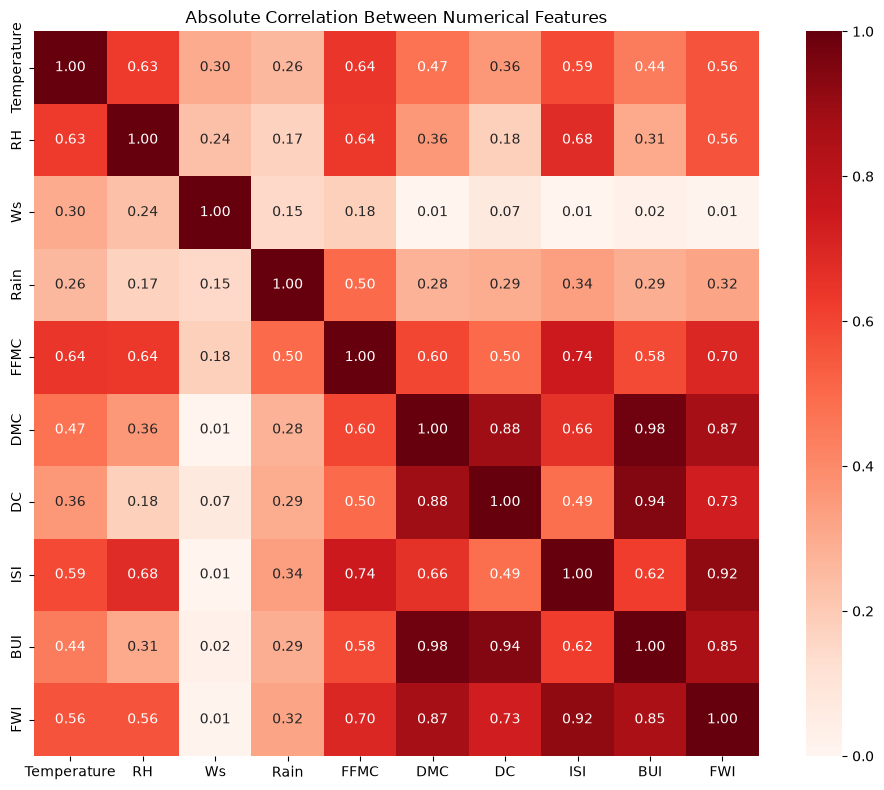

In [7]:
correlation_matrix = train_df[numeric_features].corr().abs()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=1,
    square=True
)

plt.title("Absolute Correlation Between Numerical Features")
plt.tight_layout()
plt.show()


### 2.4 Numerical Features Versus the Target


In [8]:
train_df.groupby("Classes")[numeric_features].median().T

Classes,fire,not fire
Temperature,34.00,30.0
RH,56.50,70.0
Ws,15.00,15.0
Rain,0.00,0.6
FFMC,87.90,69.7
DMC,18.10,5.7
DC,55.65,10.0
ISI,6.90,1.3
BUI,20.85,5.8
FWI,10.60,0.7


### 2.5 Categorical and Temporal Features


In [9]:
# region versus target
pd.crosstab(
    train_df["Region"],
    train_df["Classes"],
    normalize="index"
).round(3) * 100


Classes,fire,not fire
Region,,
Cordillera,50.0,50.0
Hudson Bay,62.9,37.1


In [10]:
# month versus target
pd.crosstab(
    train_df["month"],
    train_df["Classes"],
    normalize="index"
).round(3) * 100


Classes,fire,not fire
month,,
6,45.7,54.3
7,58.8,41.2
8,80.0,20.0
9,39.6,60.4


In [11]:
# Does year vary?
train_df["year"].nunique()


1

### 2.6 EDA Conclusions

- The target classes are reasonably balanced, with approximately 56% `fire`
  observations and 44% `not fire` observations. No class-balancing technique
  is required at this stage.

- Several numerical features, particularly `Rain`, `DMC`, `DC`, `ISI`, `BUI`,
  and `FWI`, show noticeable right-skewness, while `FFMC` is skewed in the
  opposite direction. These distributions will be considered later when
  designing preprocessing pipelines rather than transformed automatically.

- Several Fire Weather Index variables are strongly correlated. In particular,
  `DMC`, `DC`, `BUI`, `ISI`, and `FWI` contain substantial overlapping
  information. All features will initially be retained, while feature
  reduction or PCA may later be evaluated using cross-validation.

- Fire observations generally have higher median values of `Temperature`,
  `FFMC`, `DMC`, `DC`, `ISI`, `BUI`, and `FWI`, while they have lower median
  `RH` and `Rain`. Wind speed shows little difference between the two classes.

- The proportion of fire observations differs somewhat by region and month,
  suggesting that `Region` and seasonal information may be useful predictors.

Overall, the EDA suggests that the dataset contains meaningful separation
between the two target classes, while also highlighting skewness and
multicollinearity that should be considered during model preprocessing.


## 3. Feature Engineering

The original `day`, `month`, and `year` variables are replaced with `DayOfYear`, which provides a single continuous measure of chronological position within the year. `year` is constant across all observations and therefore contains no predictive information.


In [12]:
# Create DayOfYear for both the training and test sets
train_date = pd.to_datetime(train_df[["year", "month", "day"]])
test_date = pd.to_datetime(test_df[["year", "month", "day"]])

train_df["DayOfYear"] = train_date.dt.dayofyear
test_df["DayOfYear"] = test_date.dt.dayofyear

# Replace the original calendar components with DayOfYear
train_df = train_df.drop(columns=["year", "month", "day"])
test_df = test_df.drop(columns=["year", "month", "day"])

train_df.info()
test_df.info()


<class 'pandas.DataFrame'>
Index: 195 entries, 52 to 189
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  195 non-null    int64  
 1   RH           195 non-null    int64  
 2   Ws           195 non-null    int64  
 3   Rain         195 non-null    float64
 4   FFMC         195 non-null    float64
 5   DMC          195 non-null    float64
 6   DC           195 non-null    float64
 7   ISI          195 non-null    float64
 8   BUI          195 non-null    float64
 9   FWI          195 non-null    float64
 10  Classes      195 non-null    str    
 11  Region       195 non-null    str    
 12  DayOfYear    195 non-null    int32  
dtypes: float64(7), int32(1), int64(3), str(2)
memory usage: 24.6 KB
<class 'pandas.DataFrame'>
Index: 49 entries, 198 to 133
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  49 non-null     int

## 4. Save Engineered Train and Test Sets


In [13]:
train_df.to_csv("forest_fires_train_engineered.csv", index=False)
test_df.to_csv("forest_fires_test_engineered.csv", index=False)
